<a href="https://colab.research.google.com/github/abigiyaDa/AfriSMAT---CM4A-2026---WORKSHOP-PROGRAM/blob/main/SSM_workshop_STUDENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
---

<table style="border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:middle; width:500px;">
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/afrismat_logo.png" width="460">
</td>
<td style="border:none; vertical-align:middle;">

# **AfriSMAT  |  Circular Mechatronics for Africa (CM4A) Workshop 2026**

</td>
</tr></table>

---
---

# **Day 2 - Speed and Separation Monitoring for Collaborative Applications**

**Three sessions, 135 minutes, six cells to fill.**

You build a controller that follows a path, then change one function and it
becomes safe around a person.

Blanks are marked `...`. Each has a **hint above** and an **answer below the
check** — that order is deliberate.

| | |
|---|---|
| `q`, `q̇` | joint angles and joint speeds |
| `s`, `α` | how far round the ring; fraction of nominal speed |
| `J` | Jacobian: joint speeds → speed in space |
| `v_r`, `v_h` | robot speed; speed of the nearest part of the person |
| `p_h` | the person's position |
| `d` | distance actually available |
| `ξ` | slack variable |
| `N`, `ΔT` | plan length; control period |

---
## Setup

Run this first. The figures below will not appear until it has finished — they
are loaded from the repository, and the `pip install` takes 30–60 seconds on a
fresh runtime.

In [1]:
import os
if not os.path.isdir('/content/ssm'):
    !git clone -q https://github.com/JohnEkD/ssm-workshop.git /content/ssm
%cd /content/ssm
import sys; sys.path.insert(0, '/content/ssm/shared/lib')
!pip -q install casadi==3.7.2 2>/dev/null

import numpy as np, matplotlib.pyplot as plt, casadi as ca
import ssm_cell as sc, ring_cell as rc, ssm_viz as viz, ssm_grader as grader

print(f"  C + Zd + Zr = {sc.C_LUMP} m     T_r = {sc.T_R} s     a = {sc.A_MAX} m/s^2")
print(f"  ring: centre ({rc.CX}, {rc.CY}),  R = {rc.R} m,  corridor {1000*rc.CORRIDOR:.0f} mm")
print(f"  plan length N = {sc.N} at dT = {sc.DT} s;  {len(rc.MONITORED)} monitored points")

/content/ssm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 MB 9.6 MB/s eta 0:00:00
  C + Zd + Zr = 0.208 m     T_r = 0.2 s     a = 13.5 m/s^2
  ring: centre (0.5, 0.3),  R = 0.15 m,  corridor 5 mm
  plan length N = 10 at dT = 0.1 s;  4 monitored points


In [2]:
x_ = ca.SX.sym('x')
three_squared = float(ca.Function('f', [x_], [x_ ** 2])(3.0))
grader.q_d1_install(ca.__version__, three_squared)

  PASS  0.1  CasADi 3.7.2 imports and evaluates


True

---
---
### **One switch before we start**

Animations can be rendered two ways. **A GIF** just plays — small, quick, fine
for a first look. **A player** gives you play, pause, and a scrub bar, so you
can stop *on* the moment the arm slows and step through it a frame at a time.

The player is worth about 3 MB and 8 seconds each. Set `PLAYER = True` if you
want to be able to rewind.

---
---

In [3]:
PLAYER = False          # True -> scrubbable player;  False -> plain GIF

import matplotlib.pyplot as plt
from IPython.display import Image, HTML
plt.rcParams['animation.embed_limit'] = 100

def show(log, name):
    """Render one run. Rewind-able if PLAYER, otherwise a GIF."""
    anim = viz.animate_ring(log, rc.s_p_min)
    if PLAYER:
        out = HTML(anim.to_jshtml(fps=10))
    else:
        anim.save(f'{name}.gif', writer='pillow', fps=10, dpi=80)
        out = Image(filename=f'{name}.gif')
    plt.close('all')
    return out

---
---
# **SESSION 1 — Building a path-following controller**
### **questions 1–2**

## **1.1 The task**

A robot arm scans a part clamped to a bench. It follows a circle of radius
0.15 m and must stay within **5 mm** of it, or the scan is worthless.

Reach is 0.9 m — a small collaborative robot on a benchtop. The geometry is
fixed by the part. The only thing you can choose is **how fast to go**.

**The cell is fenced.** Nobody can be inside it while the robot runs, so
nothing in this session is about safety. That changes in session 2.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/cell_robot_only.png" width="520">
</center>

> **Why a scan and not a weld.** Slowing down is only a safety measure if it
> does not damage the work. Weld heat input is $H = \eta VI / v$ — halve the
> travel speed and you double the heat, producing a different and probably
> defective joint. A scan is the opposite: quality depends on how long you
> dwell, so slowing costs seconds and never costs a defect.
>
> **Name three tasks that would fail this test.** If you cannot, you cannot
> tell a safety measure from a way of producing defective parts slowly.

---
## **1.2 What an optimiser does**

You give it three things:

- **variables** — the numbers it may choose
- **an objective** — the thing to make small
- **constraints** — what must be true, whatever else happens

A marble in a bowl. The bowl is the objective; a wall in the bowl is a
constraint. Without the wall the marble sits at the bottom.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/bowl_unconstrained.png" width="440"><br>
<em>Minimise $(x-3)^2$. The marble rolls to the bottom.</em>
</center>

$$\min_x\;(x-3)^2 \qquad\text{then}\qquad \min_x\;(x-3)^2 \;\;\text{s.t.}\;\; x \ge 5$$

### **⏸ Predict first**

Where does the solver land on the first problem? On the second?
**Write both numbers down before running anything.**

> **A cost and a constraint are not the same thing.** A cost says *prefer not
> to*. A constraint says *not permitted*. Only one of those is a safety
> function.

### **Question 1 — the marble**

<details>
<summary><b>Hint</b></summary>

A constraint must be handed to `opti.subject_to(...)`.

Writing the comparison on a line by itself does nothing at all — and does it without warning.

</details>

In [8]:
opti = ca.Opti()
x = opti.variable()
opti.minimize((x - 3) ** 2)
opti.subject_to(x >= 5)                                    # the wall:  x >= 5
opti.solver('ipopt', {'ipopt.print_level': 0, 'print_time': 0})
x_star = float(opti.solve().value(x))
x_star

4.999999950626583

In [9]:
print(f"  constrained minimiser:  x* = {x_star:.6f}")
grader.q_d1_marble(x_star)

  constrained minimiser:  x* = 5.000000
  PASS  1.1  the constrained minimiser sits ON the constraint


True

<details>
<summary><b>Show the answer</b></summary>


```python
opti.subject_to(x >= 5)
```

`x >= 5` alone produces `True` or `False`, which is then thrown away. Nothing
happens and nothing complains. **This is the most common CasADi mistake, and
it gives no error message.**


</details>

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/bowl_constrained.png" width="440"><br>
<em>With the wall: it rests against it, not in the bowl.</em>
</center>

The answer is **5**, not 3. A constrained answer sits **on** its constraint —
giving away nothing more than it must.

---
---
## **1.3 The marble in standard form**

The marble is already in the standard form used below. It simply has almost
nothing in it.

| standard form | the marble |
|---|---|
| variables $x_0 \dots x_N$, $u_0 \dots u_{N-1}$ | one variable, $x$ |
| objective $\sum \ell(x_k, u_k)$ | one term, $(x-3)^2$ |
| $x_0 = x(t)$ — tied to the real state | nothing to tie to |
| $x_{k+1} = f(x_k, u_k)$ — the model | no time, so no model |
| $u \in U$ — actuator limits | none |
| $g(x_k) \ge 0$ — safety | $x - 5 \ge 0$ |

So the marble is **the same problem with the time taken out.**

Everything after this adds one thing back:

| | adds | you get |
|---|---|---|
| marble | — | one instant |
| + model, N steps | $x_{k+1} = f(x_k, u_k)$ | a **plan** |
| + measurement each step | $x_0 = x(t)$ | a **loop** |
| + kinematics | $x$ means joint angles | an **arm** |
| + a moving constraint | $g$ depends on a person | **safety** |

> Nothing new is invented after this point. The six lines you just wrote are
> the six lines the cell uses — with more in each.

---
---

## **1.4 How a predictive controller works**

A robot cannot be controlled one instant at a time, because stopping takes
time. So the controller chooses a **plan**: N commands covering the next N
steps.

$$\begin{aligned}
\min\;\; & \sum_{k=0}^{N-1} \ell(x_k, u_k) \\
\text{s.t.}\;\; & x_0 = x(t) && \text{measured, now} \\
& x_{k+1} = f(x_k, u_k) && \text{the model} \\
& u_k \in U && \text{actuator limits} \\
& g(x_k) \ge 0 && \text{safety}
\end{aligned}$$

- $x_0 = x(t)$ ties the plan to the real arm. Without it the solver plans a
  perfect trajectory starting somewhere the arm is not.
- $x_{k+1} = f(x_k, u_k)$ is how the solver knows a command now has
  consequences later.
- $g(x_k) \ge 0$ is where the safety rule goes, in session 3.

**This is one optimisation problem, exactly like §1.2 — a bowl with walls.
Only bigger.**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/d1_nmpc_loop.png" width="700">
</center>

### **Then it throws most of the answer away**

```
1. measure where the arm actually is
2. solve the problem above
3. apply only u₀
4. discard u₁ … u_{N−1}
5. wait ΔT, go back to 1
```

This is a **receding horizon** — the plan slides forward one step each time.

- **k** counts steps in the *plan*. Imagined.
- **step** counts steps in *reality*. One command applied per step.

Because the controller constrains a *plan*, every constraint must hold at
**every step of that plan** — which is why the safety rule sits inside a loop
over k.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/receding_horizon.png" width="540"><br>
<em>N steps planned, one applied, the rest discarded.</em>
</center>

### **Why "nonlinear"**

$f$ and $g$ are nonlinear: position involves cos and sin of the joint angles,
and the safety constraint involves a square root. There is no formula for the
answer — each step is solved numerically, from scratch, ten times a second.

That is also why **the way you write a constraint** matters, which §3.2 is
about.

### How long must the plan be?

$$T_{stop} = \frac{v}{a}, \qquad d_{brake} = \frac{v^2}{2a}$$

> **A plan shorter than the stopping time cannot see the stop it must make.**
>
> **Work through on your own:** the drone section of the Day 1 notebook runs a
> vehicle at a wall with six plan lengths. **0.8 s and shorter cannot be
> solved at all** against a 1.5 s stopping time.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/horizon_vs_stopping.png" width="600">
</center>

---
## **1.5 Where the arm is, and how fast it moves**

Two links, $L_1 = 0.5$ m and $L_2 = 0.4$ m.

**$q_1$ is measured from the x-axis. $q_2$ is measured from link 1** — the way
your forearm angle is relative to your upper arm, not to the room. In room
coordinates link 2 points along $q_1 + q_2$.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/two_links.png" width="460">
</center>

### **Where any point on the arm is**

$$p(q; a, b) = \begin{bmatrix} a\cos q_1 + b\cos(q_1+q_2) \\
a\sin q_1 + b\sin(q_1+q_2) \end{bmatrix}$$

$a$ is how far along link 1, $b$ how far along link 2. **Two separate
distances, not one running total** — past the elbow, $a$ stays at $L_1$ and
only $b$ grows.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/ab_parametrisation.png" width="620">
</center>

One formula covers every point. That is why the safety constraint can cover
the whole arm — and it must, because **the elbow can swing towards the person
while the tool moves away.**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/monitored_points.png" width="480"><br>
<em>Four monitored points, one person. Which is closest?</em>
</center>

In [10]:
q_demo = np.array([0.047, 1.816])
p_op   = np.array([0.55, -0.15])
for a, b, name in [(rc.L1/2, 0, 'mid upper arm'), (rc.L1, 0, 'elbow'),
                   (rc.L1, rc.L2/2, 'mid forearm'), (rc.L1, rc.L2, 'tool')]:
    d = np.linalg.norm(rc.arm_point(q_demo, a, b) - p_op)
    print(f"  {name:14s}  {d:.3f} m")

  mid upper arm   0.341 m
  elbow           0.181 m
  mid forearm     0.381 m
  tool            0.581 m


The **elbow** is more than three times closer than the hand. A controller
watching only the tool would swing an elbow at somebody while the hand
retreats.

### **How fast that point is moving**

$$J(q; a, b) = \begin{bmatrix}
-a\sin q_1 - b\sin(q_1+q_2) & -b\sin(q_1+q_2) \\
 a\cos q_1 + b\cos(q_1+q_2) &  b\cos(q_1+q_2) \end{bmatrix}
\qquad \dot p = J(q)\,\dot q$$

**$J$ is the Jacobian.** $q_1$ appears in **both** columns, because it rotates
both links. $a$ appears only in column 1, because $q_2$ moves only link 2.

> **The speed of a point on the arm is $\lVert J(q)\,\dot q \rVert$.** Every
> safety constraint from here onwards is a limit on that quantity, at four
> points, at every step of the plan.

### **One pose to avoid**

At $q = [0, 0]$ the arm is straight out, the two columns of $J$ become
parallel, and there is a direction the tool cannot move in at any joint speed.
This is a **singularity**, and a solver given one will either fail or return
enormous joint speeds.

### **What the controller does *not* need**

**No inverse kinematics, no dynamics.** It commands joint speeds, so the model
is simply $\dot q = u$.

A deliberate choice: the friction term in a full dynamic model changes
extremely sharply near zero speed — exactly where a robot moving slowly for
safety spends its time. Inside a solver that costs 7–13 times the iterations,
and sometimes fails completely.

### **Turning a rate into a rule about samples**

The solver works with values at instants $\Delta T$ apart, so it needs a rule
linking one to the next. Take the definition of a derivative and stop before
the limit:

$$\dot q \approx \frac{q_{k+1} - q_k}{\Delta T}
\qquad\Longrightarrow\qquad
q_{k+1} = q_k + \dot q_k \,\Delta T$$

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/time_discretisation.png" width="640">
</center>

This is **forward Euler** — assume the rate is constant across each interval
and multiply by its length. *Distance = speed × time*, one step at a time.

Here it is not even an approximation: the controller really does hold one
joint speed constant for the whole interval.

> **This is the $f$ from §1.4.** The figure also shows why **q has N+1 points
> but u has N** — fence posts and panels.

---
---
## **1.6 The path, and one number for speed**

The tool must follow a circle of radius $R$ about a centre $(c_x, c_y)$. Write
that as a function of a single number **s**:

$$x_{des}(s) = \begin{bmatrix} c_x + R\cos(2\pi s) \\
c_y + R\sin(2\pi s) \end{bmatrix}$$

One full turn is $s = 1$. At $s = 0$ the tool sits due east of the centre, and
increasing $s$ moves it **anticlockwise**.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/path_parameter.png" width="520">
</center>

### **Question 2 — the path**

<details>
<summary><b>Hint</b></summary>

The equation is directly above. `x` uses cos; `y` uses sin, about the centre `rc.CY`.

</details>

In [13]:
def ring_point(s):
    th = 2 * np.pi * s
    return np.array([rc.CX + rc.R * np.cos(th), rc.CY + rc.R * np.sin(th)])

In [14]:
grader.q_ring(ring_point, rc.R, rc.CX, rc.CY)

  PASS  the ring is closed: s and s+1 are the same point
  PASS  every path point is R from the centre


True

In [15]:
try:
    for s in (0.0, 0.25, 1.0, 1.25):
        print(f"  s = {s:.2f}  ->  {np.round(ring_point(s), 3)}")
except TypeError:
    print("  fill the blank above first, then re-run this cell")

  s = 0.00  ->  [0.65 0.3 ]
  s = 0.25  ->  [0.5  0.45]
  s = 1.00  ->  [0.65 0.3 ]
  s = 1.25  ->  [0.5  0.45]


<details>
<summary><b>Show the answer</b></summary>


```python
def ring_point(s):
    th = 2 * np.pi * s
    return np.array([rc.CX + rc.R * np.cos(th), rc.CY + rc.R * np.sin(th)])
```

No modulo and no clamp. `np.cos` already repeats every full turn, so
`ring_point` does too — which is exactly what lets s run past 1.


</details>

Notice that `s = 0.25` and `s = 1.25` give the **same point**. That is the
property the next paragraph depends on.

### How fast s should advance

$$\dot s = \alpha \, \bar{\dot s}, \qquad \alpha \in [0, 1]
\qquad\Longrightarrow\qquad
s_{k+1} = s_k + \alpha_k \,\bar{\dot s}\, \Delta T$$

$\alpha$ is the fraction of nominal speed: 1 is full speed, 0 is stopped.

> **$\alpha$ is the only freedom the task leaves.** The path is fixed by the
> part, and once $\alpha$ is chosen the joint speeds follow.

### s is a lap count, not a fraction

The ring is closed, so s has no upper limit. Capping it at 1 makes the arm slow
down as it approaches a finishing line that does not exist. Measured, that cap
added **3.4 s** to a 3.75 s scan.

---
## 1.7 The complete controller

$$\begin{aligned}
\min \;\; & \sum_k \left[ W_c e_{c,k}^2 + W_l e_{l,k}^2
   + W_\alpha (1-\alpha_k)^2 + W_u \lVert \dot q_k \rVert^2 \right] \\
\text{s.t.}\;\; & q_0 = q(t), \;\; s_0 = s(t) \\
& q_{k+1} = q_k + \dot q_k \Delta T \\
& s_{k+1} = s_k + \alpha_k \bar{\dot s} \Delta T \\
& \lVert p_{tool}(q_k) - x_{des}(s_k) \rVert^2 \le \rho^2
   && \text{the 5 mm corridor} \\
& |\dot q| \le \dot q_{max}, \;\; 0 \le \alpha \le 1 \\
& \lVert J_i(q_k)\,\dot q_k \rVert^2 \le v_{max}^2
   && \text{the speed limit}
\end{aligned}$$

Every line is something you have now seen: the standard form from §1.4, the
kinematics from §1.5, the path from §1.6.

### The two error terms

$$e = p_{tool}(q) - x_{des}(s), \qquad
e_c = e \cdot n, \qquad e_l = e \cdot t$$

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/contour_lag_error.png" width="560">
</center>

Being **off the ring** is a quality failure. Being **early or late along it**
is not. Splitting the error lets the cost weight them differently.

**The corridor is a limit on position, not on velocity.** You could instead
require the tool's velocity to point along the ring — the more natural thing
to write. Do not: small errors in direction add up, and at 10 Hz that drift
reaches **15–26 mm**, five times the corridor.

**The last line is the one that changes.** For now $v_{max}$ is a fixed
**0.30 m/s** — a number somebody typed in.

In [16]:
def fixed_cap(opti, J, dq, p, p_h, v_h, eps_k, Te):
    """A speed limit somebody typed. Note p_h -- the person's position --
    is an argument it never uses."""
    opti.subject_to(ca.sumsqr(J @ dq) <= 0.30 ** 2)

---
## 1.8 Running it

> `simulate` always takes a protective-stop rule as its second argument. With
> nobody in the cell it never fires, and session 2 explains what it is.

In [17]:
step_fn, _ = rc.build_expert(cap_fn=fixed_cap)
# y_near = Y_FAR puts the operator at the edge and keeps them THERE.
# (y_near = -5 would also be out of range, but the marker would sprint
#  4.45 m off-screen at 2.2 m/s to get there -- distracting, and faster
#  than the standard's own walking assumption.)
log_fenced = rc.simulate(step_fn, rc.s_p_min, y_near=rc.Y_FAR,
                         label='fenced, nobody working in the cell')
z = rc.audit(log_fenced)

Now watch it. The arm, the ring, and the speed it chose:

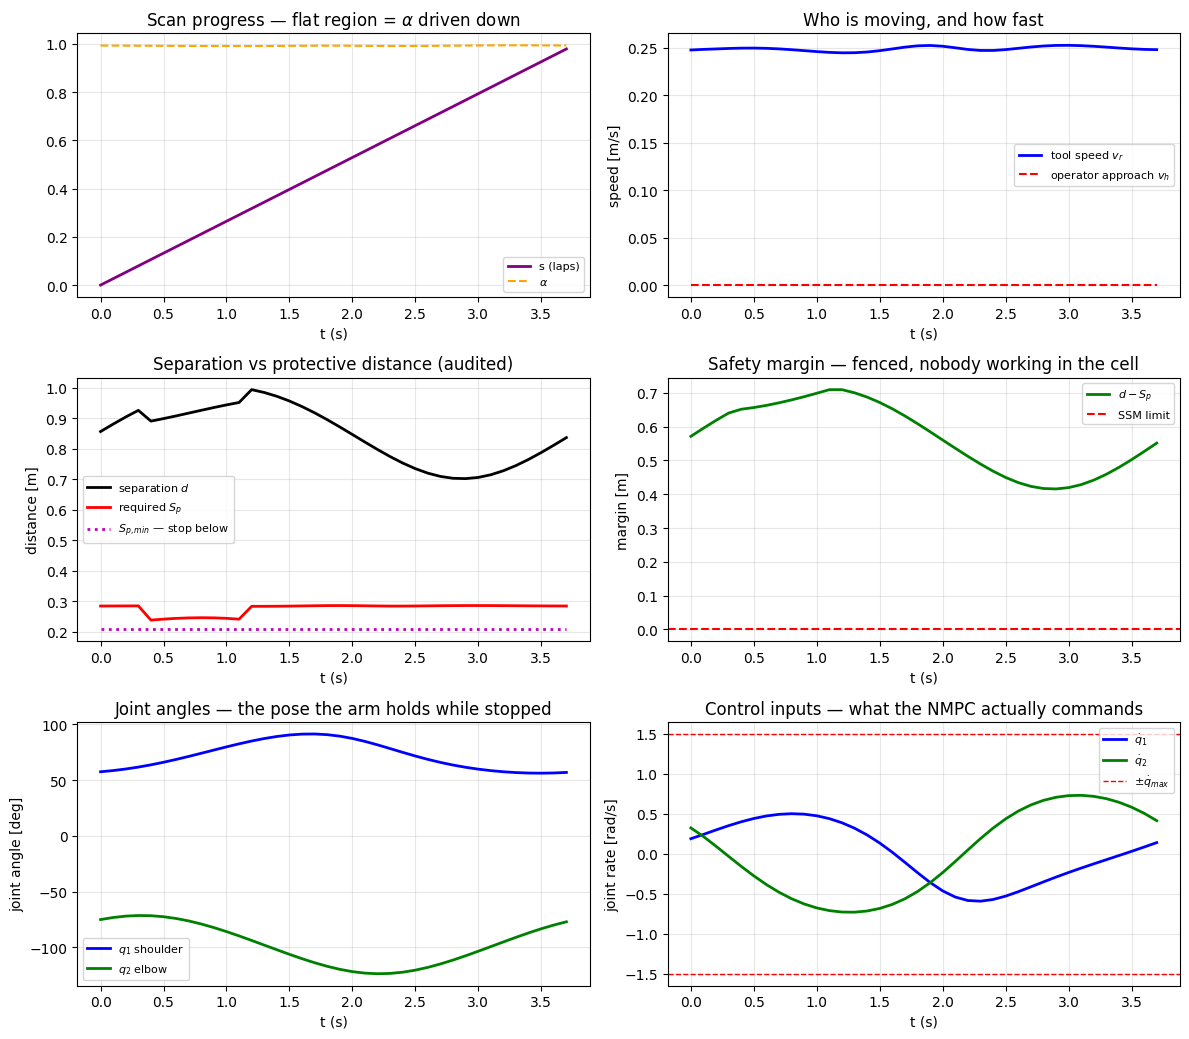

In [18]:
viz.plot_ring_run(log_fenced, rc.s_p_min); plt.show()

`alpha` sits at 1.0 for the whole run — nothing is asking it to slow down.
Remember that shape; in session 3 it will look very different.

### Why $S_p$ moves when nobody does

Look at the middle-left panel. The operator is standing still — $v_h$ is
**exactly zero** for the whole run — yet the red required-distance line jumps
around by about 48 mm.

That is the arm, and it is worth understanding now rather than in session 3.
$S_p$ is recomputed at **each of the four monitored points**, from that
point's own Cartesian speed, and the plot shows whichever point is closest to
being in trouble. Two things change underneath it:

- **which point is worst** — sometimes the tool, sometimes the upper-arm mid
- **how fast that point is going** — a point near a pivot barely moves, while
  the tool runs at the full 0.25 m/s

The steps in the line are the moment the worst point switches from one to the
other. A single-point implementation would give a smooth, almost flat line —
and would be wrong, because the elbow can be the constraining part while you
are watching the tool.

And the arm itself. **This takes 10–20 seconds to render.**

The marker at the bottom edge is the operator, standing well clear of the
cell. Nobody is working alongside — they are simply in the frame so that the
next two animations have something to compare against.

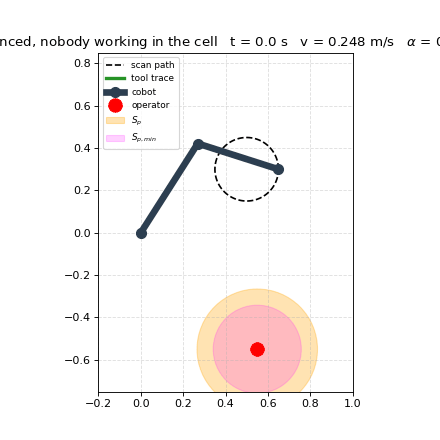

In [19]:
show(log_fenced, 'fenced')

**You have a working predictive controller** — inside a fence. It follows a
path, holds a corridor, and respects a speed limit.

Three numbers to note: the cycle time, the worst distance off the ring
(against the 5 mm allowance), and **solver failures**. That last one matters
more than it looks, and §3.4 says why.

---
---
# **SESSION 2 — The safety distance, and how to invert it**
### **questions 3–5**

## **2.1 What changes when the fence comes down**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/fence_deleted.png" width="720">
</center>

The fence is gone. **A person working alongside reaches into the workspace to
index a part. Their hand crosses 57 cm in about 3 seconds — roughly
0.2 m/s** — holds there, then withdraws the same way.

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/cell_layout.png" width="620">
</center>

> **Removing the fence does not add a feature.** It removes an assumption
> nobody ever had to write down: that nothing in the workspace can be hurt.

> We give the controller the person's true speed. **No safety-rated sensor
> measures that today**, which is why the standard tells you to assume 1.6 m/s
> instead.

The layout figure shows where the fence used to be, and the two positions
where the hand stops. **They are 8 cm apart, and that single number is the
whole difference between a compliant cell and a non-compliant one.**

---
## **2.2 The protective separation distance**

$$S_p = \underbrace{(C + Z_d + Z_r)}_{\text{sensing}}
  + \underbrace{v_h (T_r + T_s)}_{\text{they keep reaching}}
  + \underbrace{v_r T_r}_{\text{before it reacts}}
  + \underbrace{\frac{v_r^2}{2a}}_{\text{braking}}
  + \underbrace{v_r \Delta T}_{\text{between samples}}$$

Every term is **a distance covered while the robot is trying to stop.**

<center>
<img src="https://raw.githubusercontent.com/JohnEkD/ssm-workshop/main/shared/diagrams/sp_terms.png" width="640"><br>
<em>The gap, to scale, at v_r = 0.25 and v_h = 0.15 m/s.</em>
</center>


Two things to take from that bar.

**Sensing uncertainty is 71 % of the gap** — the wide red block. Everything the
robot does about its own motion is the four thin slices on the right, and they
are hard to see at true scale, which is why they are listed underneath.

**The robot's braking distance is 0.8 %.** Two and a half millimetres. Buying
an arm that stops harder buys you almost nothing; halving the sensing
uncertainty gives back a third of the cell.

### **⏸ Think first**

$T_s$ is the stopping **time**. Is it a fixed number?

---

### **Question 3 — write S_p**

<details>
<summary><b>Hint</b></summary>

`T_s` is a *time*: speed divided by deceleration.

The braking blank is a *distance*: `v_r**2 / (2 * sc.A_MAX)`.

</details>

In [22]:
def s_p(v_r, v_h):
    T_s = v_r / sc.A_MAX                         # the robot's stopping TIME
    return (sc.C_LUMP
            + v_h * (sc.T_R + T_s)     # the person keeps reaching in
            + v_r * sc.T_R             # the robot before it reacts
            + v_r ** 2 / (2 * sc.A_MAX)           # the robot braking
            + v_r * sc.DT)             # movement between samples

In [23]:
grader.q_ssm_radius(s_p, sc.C_LUMP, sc.A_MAX, sc.T_R)

  PASS  at rest with a still operator, S_p reduces to C + Z_d + Z_r
  PASS  S_p grows with robot speed
  PASS  S_p grows with operator approach speed
  PASS  T_s couples operator speed to robot speed


True

In [24]:
try:
    print(f"  S_p(0, 0.0) = {s_p(0.0, 0.0):.3f} m   a robot standing completely still")
    print(f"  S_p(0, 1.6) = {s_p(0.0, 1.6):.3f} m   ... and the speed the standard assumes")
except TypeError:
    print("  fill the blanks above first, then re-run this cell")

  S_p(0, 0.0) = 0.208 m   a robot standing completely still
  S_p(0, 1.6) = 0.528 m   ... and the speed the standard assumes


<details>
<summary><b>Show the answer</b></summary>


```python
def s_p(v_r, v_h):
    T_s = v_r / sc.A_MAX
    return (sc.C_LUMP
            + v_h * (sc.T_R + T_s)
            + v_r * sc.T_R
            + v_r ** 2 / (2 * sc.A_MAX)
            + v_r * sc.DT)
```

**$T_s$ is not a fixed number.** A faster robot takes longer to stop, so the
person has longer to keep reaching towards it. That links the two speeds —
$v_r$ appears inside the $v_h$ term as well as on its own.

The check catches a fixed $T_s$ with a mixed difference that comes out
**exactly zero** if you wrote it as a constant. Three other assertions still
pass; only that one fails.


</details>

In [25]:
try:
    mix = (s_p(0.25, 0.15) - s_p(0.25, 0.0) - s_p(0.0, 0.15) + s_p(0.0, 0.0))
    print(f"  mixed difference = {mix:.6f}     (exactly 0 if T_s is a constant)")
except TypeError:
    print("  fill the blanks above first, then re-run this cell")

  mixed difference = 0.002778     (exactly 0 if T_s is a constant)


Over half a metre of clearance for a **motionless** robot, purely because the
standard assumes the person might be approaching at 1.6 m/s.

The last term is **ours, not the standard's**: constraints are imposed only at
points $\Delta T$ apart, so we allow for one sample of movement in between.

> **Work through on your own:** at $v_r = 0.25$, $v_h = 0.15$ m/s the total
> breaks down as sensing uncertainty **71 %**, braking distance **0.8 %**.
> Buying a robot that stops harder gains almost nothing. Halving the sensing
> uncertainty gives back a third of the space.

---
---

## **2.3 The distance below which nothing is safe**

Set $v_r = 0$ in $S_p$ and every term containing $v_r$ disappears:

$$S_{p,min} = v_h T_r + C \qquad \text{(Byner eq. 8)}$$

### **Question 4 — the floor**

<details>
<summary><b>Hint</b></summary>

Two terms and no more. `sc.C_LUMP` and `sc.T_R` are the constants; the only argument is the person's speed.

If you find yourself wanting `v_r`, read the line above the formula again.

</details>

In [26]:
def s_p_min(v_h):
    return v_h * sc.T_R + sc.C_LUMP

In [27]:
grader.q_d2_spmin(s_p_min)

  PASS  3.1  with the person still, the floor is the sensing term alone
  PASS  3.2  it rises with how fast the person is walking
  PASS  3.3  it is LINEAR in the person's speed
  PASS  3.4  it does NOT depend on the robot at all


True

In [28]:
try:
    print(f"  s_p_min(0.0) = {s_p_min(0.0):.4f} m")
    print(f"  s_p_min(1.6) = {s_p_min(1.6):.4f} m")
except TypeError:
    print("  fill the blank above first, then re-run this cell")

  s_p_min(0.0) = 0.2080 m
  s_p_min(1.6) = 0.5280 m


<details>
<summary><b>Show the answer</b></summary>


```python
def s_p_min(v_h):
    return v_h * sc.T_R + sc.C_LUMP
```

**No robot term at all.** That is what makes it a floor rather than a speed
limit: below it, *no* robot speed is safe — including zero.

The check tests the **signature** as well as the arithmetic. Writing
`s_p_min(v_h, v_r)` fails on the shape, before any number is compared.


</details>

> So the protective stop sits **outside** the optimiser. It is not a speed the
> controller chooses; it is a situation the controller should never have
> reached. **This is the rule you passed to `simulate` in §1.8 — and in §2.4
> you will meet the same number from the other direction.**

---
---

## **2.4 From a distance to a speed limit**

$S_p$ tells you the distance needed *for a given speed*. The controller needs
the opposite: **given the distance available, how fast may I go?**

Set $S_p \le d$ and collect terms, remembering that $T_s = v_r/a$ puts $v_r$
into the $v_h$ term as well:

$$\tfrac12 a\, v_r^2
 + \left(T_r + \Delta T + \tfrac{v_h}{a}\right) v_r
 + \left(C + v_h T_r - d\right) \;\le\; 0$$

Solve, with $T_e = T_r + \Delta T$ and $K = C + Z_d + Z_r - d$:

$$v_{max} = \sqrt{(a T_e + v_h)^2 - 2a(K + v_h T_r)} \;-\; a T_e \;-\; v_h$$

At $\Delta T = 0$ this is **Byner eq. (7)**, and also Pupa & Secchi eq. (6).

### ⏸ Think first

The answer can come out **negative**. What does a negative speed limit mean,
and what should the function do with it?

---

### **Question 5 — invert it**

<details>
<summary><b>Hint</b></summary>

The guard is a statement about `disc`.

The return is the formula above: `np.sqrt(disc) - sc.A_MAX * T_e - v_h`.

</details>

In [29]:
def v_admissible(d, v_h):
    T_e  = sc.T_R + sc.DT
    disc = (sc.A_MAX * T_e + v_h) ** 2 - 2 * sc.A_MAX * ((sc.C_LUMP - d) + v_h * sc.T_R)
    if disc <0 :                                   # guard the square root
        return -1.0
    return np.sqrt(disc) - sc.A_MAX * T_e - v_h

In [30]:
grader.q_v_admissible(v_admissible, s_p)

  PASS  the closed form inverts S_p exactly (worst residual 4.4e-16)


True

In [31]:
try:
    for d in (0.300, 0.238, 0.210, 0.150):
        print(f"  v_admissible({d:.3f}, 0.15) = {v_admissible(d, 0.15):+.3f} m/s")
except TypeError:
    print("  fill the blanks above first, then re-run this cell")

  v_admissible(0.300, 0.15) = +0.195 m/s
  v_admissible(0.238, 0.15) = +0.000 m/s
  v_admissible(0.210, 0.15) = -0.091 m/s
  v_admissible(0.150, 0.15) = -0.293 m/s


<details>
<summary><b>Show the answer</b></summary>


```python
    if disc < 0:
        return -1.0
    return np.sqrt(disc) - sc.A_MAX * T_e - v_h
```

`np.sqrt` of a negative returns `nan`, and `nan` compared with anything is
`False` — so it passes through an `if` without complaint and appears much
later as a result nobody can explain. The guard costs one line.

**But for this cell the guard never actually fires.** The discriminant only
goes negative below $d = -0.42$ m, which is not a distance. What happens
instead is more interesting — see below.


</details>

In [32]:
try:
    d_zero = s_p_min(0.15)
    print(f"  v_max reaches zero at d = {d_zero:.4f} m")
    print(f"  s_p_min(0.15)            = {s_p_min(0.15):.4f} m")
    print(f"  v_admissible there       = {v_admissible(d_zero, 0.15):+.2e} m/s")
except TypeError:
    print("  fill the blanks above first, then re-run this cell")

  v_max reaches zero at d = 0.2380 m
  s_p_min(0.15)            = 0.2380 m
  v_admissible there       = +3.61e-16 m/s


**The same number.** That is not a coincidence, and it is worth a moment.

$S_{p,min}$ came from setting $v_r = 0$ in the forward formula. $v_{max} = 0$
comes from inverting it. **The two derivations meet exactly**, because they
are the same statement read in opposite directions.

Below that distance the formula keeps returning numbers, and they are
negative. A negative speed limit is not an instruction to reverse — it means
**no speed is compliant, including zero**, and the caller must recognise it as
such rather than clamping it to zero and driving on.

---
---

# **SESSION 3 — Adding the safety constraint**
### **question 6**

## **3.1 The fixed limit is not enough**

Same controller as session 1. Same fixed 0.30 m/s limit. Now the fence is gone
and someone is at the bench.

In [34]:
log_bad = rc.simulate(step_fn, rc.s_p_min, y_near=0.02,
                      label='fixed cap, person reaching in')
z_bad = rc.audit(log_bad)

Six panels: the states on the left, the controls bottom right, and the safety
quantities in the middle. Three of them are worth stopping on.

**Middle right — the margin.** $d - S_p$, the gap between the distance
available and the distance required. The shaded band is the protective stop.

**Middle left — the two distances.** Black is what you have, red is what the
standard demands. Watch where they meet.

**Bottom right — the joint rates.** They sit at **exactly zero** through the
shaded band. That is not a robot slowing down. That is a robot that has been
switched off, and the difference is the whole of session 3.

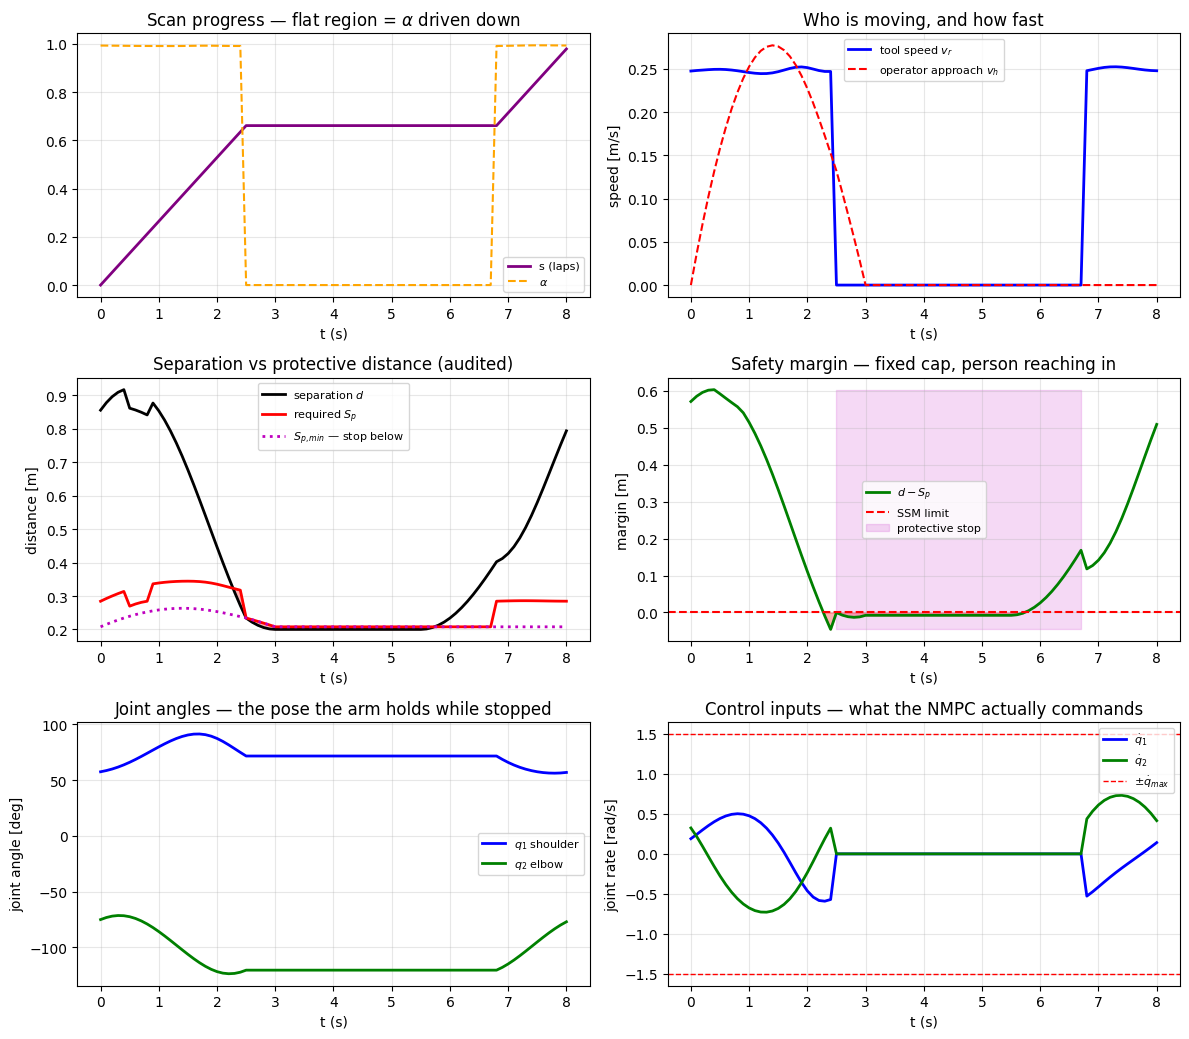

In [35]:
viz.plot_ring_run(log_bad, rc.s_p_min); plt.show()

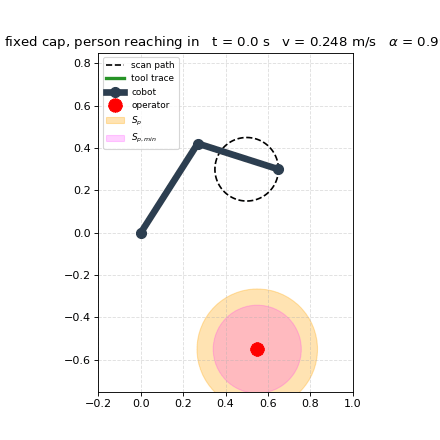

In [36]:
show(log_bad, 'fixed_cap')

Watch the hand come in and the arm **stop dead**, twice. Not slow — stop.
That is the protective stop, and it is the wrong way to be safe.

The controller is not broken — it is doing exactly what it was told. Its speed
limit is a number somebody typed in, and **that number knows nothing about
where the person is**.

Look at how long the protective stop was held on.

> **A protective stop firing repeatedly is not a safety system working. It is
> a controller that should never have got there.**

---
---

## **3.2 Writing the constraint**

$$\lVert J_i(q)\,\dot q \rVert \;\le\; v_{max,i}$$

At **four points** on the arm and **every step of the plan**.
Four × ten = **forty safety constraints per solve.**

### **Square both sides**

$$\lVert J_i(q)\,\dot q \rVert^2 \;\le\;
  \bigl(\max(v_{max,i},\,0) + \xi\bigr)^2$$

**Why not the square root.** $\sqrt{x}$ becomes infinitely steep at $x = 0$:

In [37]:
for x in (1e-2, 1e-4, 1e-6, 1e-8, 1e-10):
    print(f"  slope of sqrt(x) at x = {x:.0e}  is  {0.5 / np.sqrt(x):>10,.0f}")

  slope of sqrt(x) at x = 1e-02  is           5
  slope of sqrt(x) at x = 1e-04  is          50
  slope of sqrt(x) at x = 1e-06  is         500
  slope of sqrt(x) at x = 1e-08  is       5,000
  slope of sqrt(x) at x = 1e-10  is      50,000


The arm's speed is *exactly* zero every time it stops — which is the whole
point of this cell — and a solver that follows slopes cannot cope with that.
Squaring moves the square root onto **distance**, which is never near zero.

Squared, the constraint is quadratic in the decision variables, so each solve
is a **quadratically constrained** problem — a well-studied class.

**Why max(·, 0).** $v_{max}$ can come out negative, meaning no speed is safe.
Square a negative and you get a positive — turning a "stop" into a "go".

**$\xi$** is a slack variable: expensive enough that the optimiser never uses
it, present so the problem can always be solved.

> **Work through on your own:** the failure-demo section of the Day 2 notebook
> runs the square-root version. It fails to solve on **28 of 76 steps**,
> returning zero speed each time.

### **Two pieces of syntax**

`J @ u` is matrix multiplication. **`J * u` is not** — it multiplies element by
element and gives the wrong shape, with no error.
`ca.fmax(x, 0)` is `max(x, 0)` for symbols.

### **Question 6 — the safety constraint**

The first three lines are **question 5** written for symbols — `ca.sqrt`
instead of `np.sqrt`. Note the first line: this is where `p_h`, unused by
`fixed_cap`, finally does something.

<details>
<summary><b>Hint</b></summary>

First blank: the vector whose squared length the cap bounds — the Jacobian of this point times the joint speeds.

Second blank: the admissible speed, clamped before it is squared.

</details>

In [38]:
def speed_cap(opti, J, dq, p, p_h, v_h, eps_k, Te):
    d = ca.sqrt(ca.sumsqr(p - p_h) + 1e-8)
    disc  = (sc.A_MAX*Te + v_h)**2 - 2*sc.A_MAX*((sc.C_LUMP - d) + v_h*sc.T_R)
    v_max = ca.sqrt(ca.fmax(disc, 1e-12)) - sc.A_MAX*Te - v_h
    opti.subject_to(ca.sumsqr(J @ dq) <= (ca.fmax(v_max, 0.0) + eps_k)**2)

In [39]:
grader.q_speed_cap_form(speed_cap)

  PASS  4.1  the tool is held at the admissible speed (0.2558 vs 0.2558 m/s)
  PASS  4.2  the square root is on DISTANCE, never on speed


True

<details>
<summary><b>Show the answer</b></summary>


```python
    opti.subject_to(ca.sumsqr(J @ dq) <= (ca.fmax(v_max, 0.0) + eps_k)**2)
```

Three protections, each necessary:

- `fmax(disc, 1e-12)` prevents a `nan`
- `fmax(v_max, 0)` prevents a negative limit becoming a permission
- `sumsqr` on both sides keeps every square root on **distance**


</details>

---
---

## **3.3 Running it again**

Same ring. Same corridor. Same objective. Same solver.
**One function replaced.**

In [40]:
safe_fn, _ = rc.build_expert(cap_fn=speed_cap)
runs, logs = {}, {}
for label, y in [('nobody present', -5.0),
                 ('person reaching in', 0.02),
                 ('compliant layout', -0.06)]:
    logs[label] = rc.simulate(safe_fn, s_p_min, y_near=y, label=label)
    runs[label] = rc.audit(logs[label])

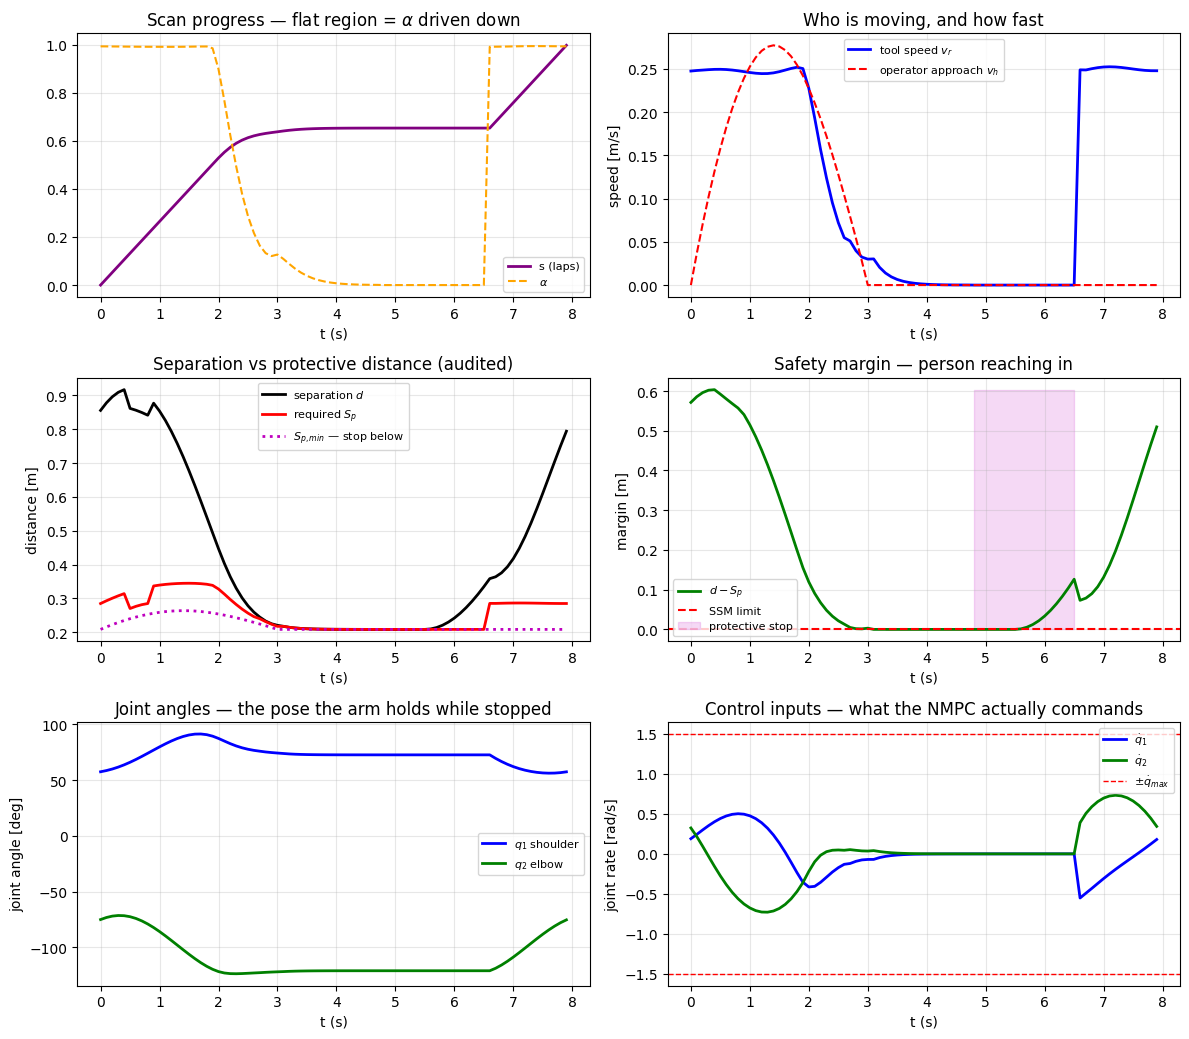

In [41]:
viz.plot_ring_run(logs['person reaching in'], s_p_min); plt.show()

Compare this with §3.1, panel by panel.

**Top left — $\alpha$ now curves down and back up.** The robot slows in
anticipation and recovers, instead of dropping to a flat zero and waiting.

**Bottom right — the joint rates never flatline.** The arm is moving, slowly,
throughout. Being safe and being stopped are no longer the same thing.

**Middle left — the black line rides the red one.** Once the person is close,
separation sits *exactly* on the required distance and follows it up and down.
That is the marble against its wall from §1.2 — a constrained optimum giving
away nothing more than it must, now with a wall that moves.

And the same episode with the safety constraint in place. If you set
`PLAYER = True` at the top, scrub to about 3 seconds in both this and the
§3.1 animation — that is where the two controllers part company.

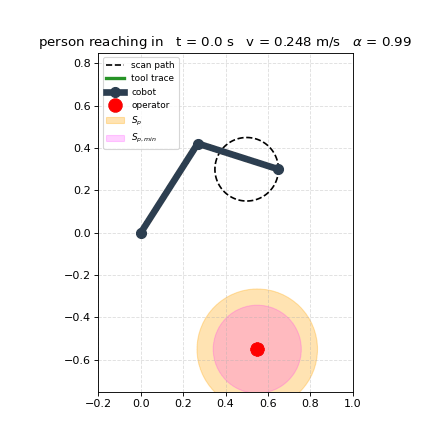

In [42]:
show(logs['person reaching in'], 'safe')

### **The comparison that matters**

Both versions took about the same time. **The time is not what changed.**

In [43]:
p = runs['person reaching in']
print(f"  {'':22s} {'fixed limit':>14s} {'safety constraint':>19s}")
print(f"  {'cycle time':22s} {z_bad['cycle']:>12.1f} s {p['cycle']:>17.1f} s")
print(f"  {'TOO CLOSE BY':22s} {z_bad['breach_mm']:>11.2f} mm {p['breach_mm']:>16.2f} mm")
print(f"  {'stop held on for':22s} {z_bad['still_latched_s']:>12.1f} s {p['still_latched_s']:>17.1f} s")
print(f"  {'solver failures':22s} {z_bad['still_failed_s']:>12.1f} s {p['still_failed_s']:>17.1f} s")

                            fixed limit   safety constraint
  cycle time                      8.1 s               8.0 s
  TOO CLOSE BY                 45.91 mm             0.02 mm
  stop held on for                4.3 s               1.8 s
  solver failures                 0.0 s               0.0 s


> **On the 0.02 mm.** The safety constraint does not print an exact zero. That
> is 20 microns against a 208 mm requirement — the residue of a numerical
> solve with a slack variable, not a real incursion. What matters is the two
> orders of magnitude between it and 45.91 mm.

The fixed limit spent that time **stopped, after the fact**. The safety
constraint spends it **slowing down beforehand**. Same duration, and only one
of them stays outside the required distance.

Against a cell with nobody in it, the difference between the empty-cell cycle
time and this one is what safety costs — measured on the same controller
twice.

### **The surprising part**

The required separation is **largest while the hand is still approaching**,
and *falls* once it arrives and holds still. The robot is most restricted when
the person is furthest away — because $v_h(T_r + T_s)$ depends on **approach
speed**, not on how close they are.

### **Compliant and non-compliant can never overlap**

The protective stop fires only in the non-compliant layout. Compliance
requires the closest approach to be at least $C$; the stop fires when the
distance is below $C$. Same threshold, opposite sides — **they cannot both
happen.** If your protective stop fires, you have found a layout problem, not
a tuning problem.

---
---
## **3.4 The number to always report**

Report **solver failures** separately, always.

> **A solver that fails silently looks exactly like a robot being safe.** If
> that number is not zero, what you are looking at is not a safety
> demonstration.

---
---
## **3.5 The check**

In [44]:
grader.reset()
grader.q_d1_marble(x_star)
grader.q_ring(ring_point, rc.R, rc.CX, rc.CY)
grader.q_ssm_radius(s_p, sc.C_LUMP, sc.A_MAX, sc.T_R)
grader.q_d2_spmin(s_p_min)
grader.q_v_admissible(v_admissible, s_p)
grader.q_speed_cap_form(speed_cap)
grader.summary()

  PASS  1.1  the constrained minimiser sits ON the constraint
  PASS  the ring is closed: s and s+1 are the same point
  PASS  every path point is R from the centre
  PASS  at rest with a still operator, S_p reduces to C + Z_d + Z_r
  PASS  S_p grows with robot speed
  PASS  S_p grows with operator approach speed
  PASS  T_s couples operator speed to robot speed
  PASS  3.1  with the person still, the floor is the sensing term alone
  PASS  3.2  it rises with how fast the person is walking
  PASS  3.3  it is LINEAR in the person's speed
  PASS  3.4  it does NOT depend on the robot at all
  PASS  the closed form inverts S_p exactly (worst residual 4.4e-16)
  PASS  4.1  the tool is held at the admissible speed (0.2558 vs 0.2558 m/s)
  PASS  4.2  the square root is on DISTANCE, never on speed

  14 / 14 checks passed


True

---
---

## **Three sentences to leave with**

1. **A controller can only respect what appears in its equations.**
2. **A plan shorter than the stopping time cannot see the stop it must make.**
3. **A cost says "prefer not to". A constraint says "not permitted". Only one
   of those is a safety function.**

---
---
## **To work through on your own**

Two further notebooks, linked below. Each section runs on its own — hints
above each blank, answers below each check.

| section | what it shows | time |
|---|---|---|
| [Foundations §2](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_1_foundations/selfstudy_1_foundations.ipynb) — PD on real inertia | overshoot 39.3° → 4.9° → 0.0°, but **steady error 2.99° in all three** | 10 min |
| [Foundations §3](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_1_foundations/selfstudy_1_foundations.ipynb) — the wall | eighteen gain pairs, the best still crosses by 54 mm, **none reach zero** | 15 min |
| [Foundations §4](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_1_foundations/selfstudy_1_foundations.ipynb) — the drone | **0.8 s plans and shorter cannot be solved** against a 1.5 s stopping time | 20 min |
| [Foundations §5](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_1_foundations/selfstudy_1_foundations.ipynb) — the arm | one constraint added — **61.1 mm → 0.000 mm** | 15 min |
| [SSM cell §5](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_2_ssm_cell/selfstudy_2_ssm_cell.ipynb) — the square-root version | **fails to solve on 28 of 76 steps**, returning zero speed each time | 10 min |
| [SSM cell §6](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_2_ssm_cell/selfstudy_2_ssm_cell.ipynb) — where the distance goes | **71 % sensing, 0.8 % braking** | 10 min |
| [SSM cell §7](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_2_ssm_cell/selfstudy_2_ssm_cell.ipynb) — remove the path | **47 % of the controller unchanged** — and what survives is the safety part | 5 min |
| [SSM cell §10](https://colab.research.google.com/github/JohnEkD/ssm-workshop/blob/main/day_2_ssm_cell/selfstudy_2_ssm_cell.ipynb) — the walkthrough | 77 lines, of which the safety constraint is **five** | 10 min |

**Start with SSM cell §5.** It is ten minutes, and it is the most transferable
thing in either notebook: a constraint written the obvious way stalls the
solver, and a stalled solver looks exactly like a robot being safe.

---
---
## **Further reading**

- **C. Byner, B. Matthias and H. Ding**, "Dynamic speed and separation
  monitoring for collaborative robot applications — concepts and performance,"
  *Robotics and Computer-Integrated Manufacturing*, vol. 58, pp. 239–252, 2019.
- **A. Pupa and C. Secchi**, "A safety-aware kinodynamic architecture for
  human-robot collaboration," *IEEE ICRA*, 2024.
- **L. Grüne and J. Pannek**, *Nonlinear Model Predictive Control: Theory and
  Algorithms*, 2nd ed. Cham: Springer, 2017.
- **J. A. E. Andersson, J. Gillis, G. Horn, J. B. Rawlings and M. Diehl**,
  "CasADi — a software framework for nonlinear optimization and optimal
  control," *Mathematical Programming Computation*, vol. 11, no. 1, pp. 1–36,
  2019.
- **A. Wächter and L. T. Biegler**, "On the implementation of an interior-point
  filter line-search algorithm for large-scale nonlinear programming,"
  *Mathematical Programming*, vol. 106, no. 1, pp. 25–57, 2006.
- **B. Siciliano, L. Sciavicco, L. Villani and G. Oriolo**, *Robotics:
  Modelling, Planning and Control*. London: Springer, 2009.
- **ISO 10218-2:2025**, *Robotics — Safety requirements — Part 2*. Geneva: ISO.
- **ISO 13855:2010**, *Safety of machinery — Positioning of safeguards with
  respect to the approach speeds of parts of the human body*. Geneva: ISO.